# The Projection Mechanism for Sparse Gradients (Ghazi et al. 2024, Algorithm 1)

This notebook demonstrates the **perturb-then-project** DP mean-estimation
primitive of Ghazi, Guzmán, Kamath, Kumar & Manurangsi, *"Differentially Private
Optimization with Sparse Gradients"* (NeurIPS 2024), as implemented in `dimma`.

The mechanism adds coordinate-wise Laplace/Gaussian noise to the empirical mean of
`s`-sparse, `ℓ₂ ≤ L` records and then Euclidean-projects the noisy answer onto the
`ℓ₁`-ball `K = B₁(0, L√s)`. The projection is **post-processing** — it consumes no
privacy budget — yet it converts sparsity into a **nearly dimension-independent**
error rate driven by `‖ξ‖_∞` rather than `‖ξ‖₂` (Lemma 3.1).

**Sections**

1. Setup — bootstrap, imports, seeds.
2. Standalone mechanism on synthetic `s`-sparse data — error vs. dimension.
3. Lemma 3.1 validation — Laplace (`δ=0`) and Gaussian (`δ>0`) branches.
4. Criteo sparse model — empirical per-sample gradient-sparsity histogram.
5. SpiderBoost with projection **off vs. on** — identical accounting.
6. Caveats.


## 1. Setup

In [1]:
import sys
from pathlib import Path

# Walk up to the example root (the folder that contains lib/ and figs/) so the
# notebook runs from anywhere, then put lib/ on sys.path (same pattern as the
# other Private SpiderBoost notebooks).
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'lib' / 'model.py').is_file())
if str(ROOT / 'lib') not in sys.path:
    sys.path.insert(0, str(ROOT / 'lib'))

import jax
import jax.numpy as jnp
import numpy as np
from sklearn.metrics import roc_auc_score

import dimma
from dimma import TrainConfig, compute_noise_scales
from dimma.datasets import load_criteo
from dimma.mechanisms.projection import projection_mechanism
from dimma.models import (hashed_init_params, hashed_forward, hash_buckets,
                          per_sample_hashed_bce_loss)

import model                    # lib/model.py (expected_grad_evals lives here)
import visualization as viz     # lib/visualization.py (plot helpers)

FIGS_DIR = ROOT / 'figs'
FIGS_DIR.mkdir(exist_ok=True)

SEED = 0
np.random.seed(SEED)
rng = np.random.default_rng(SEED)
print('JAX backend:', jax.default_backend())


JAX backend: cpu


## 2. Standalone mechanism on synthetic `s`-sparse data

We fix an `s`-sparse ground-truth mean `z̄` with `‖z̄‖₂ < L` (so `z̄ ∈ K`) and
privatise it with the **Gaussian branch** across a sweep of dimensions `d`. For
each `d` we compare two errors over several trials:

- **unprojected** — `‖z̃ − z̄‖₂`, the raw noisy mean. The Gaussian scale is
  `s`-independent, so this grows like `√d`.
- **projected** — `‖ẑ − z̄‖₂`, the mechanism output. Lemma 3.1 caps it by
  `‖ξ‖_∞`, so it stays nearly flat in `d`.

We use a **modest** dimension range up to `3·10⁴`. Past `~10⁶` the `float32`
`cumsum` inside the `ℓ₁`-ball projection loses precision and JAX x64 would be
needed; we deliberately stop well short of that so the demo runs fast and exactly.


In [2]:
L = 1.0
s_syn = 20
n_syn = 10_000
eps_syn = 0.5           # Gaussian branch requires eps < 1
delta_syn = 1e-5           # Gaussian branch
dims = [100, 300, 1000, 3000, 10000, 30000]
n_trials = 20

def make_sparse_mean(d, s, L, rng, frac=0.5):
    # s-sparse vector with ||.||_2 = frac*L < L, hence inside K = B1(0, L*sqrt(s)).
    z = np.zeros(d, dtype=np.float32)
    idx = rng.choice(d, size=s, replace=False)
    vals = rng.standard_normal(s).astype(np.float32)
    vals *= (frac * L) / np.linalg.norm(vals)
    z[idx] = vals
    return z

proj_mean, proj_std, unproj_mean, unproj_std = [], [], [], []
key = jax.random.PRNGKey(SEED)
for d in dims:
    z_bar = jnp.asarray(make_sparse_mean(d, s_syn, L, rng))
    pe, ue = [], []
    for _ in range(n_trials):
        key, sub = jax.random.split(key)
        zhat, z_tilde = projection_mechanism(
            z_bar, epsilon=eps_syn, delta=delta_syn, n=n_syn,
            L=L, s=s_syn, key=sub)
        pe.append(float(jnp.linalg.norm(zhat - z_bar)))
        ue.append(float(jnp.linalg.norm(z_tilde - z_bar)))
    proj_mean.append(np.mean(pe));   proj_std.append(np.std(pe))
    unproj_mean.append(np.mean(ue)); unproj_std.append(np.std(ue))
    print(f'd={d:6d}  projected={np.mean(pe):.4f}  unprojected={np.mean(ue):.4f}')


d=   100  projected=0.0199  unprojected=0.0199


d=   300  projected=0.0332  unprojected=0.0332


d=  1000  projected=0.0615  unprojected=0.0615


d=  3000  projected=0.0781  unprojected=0.1062


d= 10000  projected=0.0688  unprojected=0.1938


d= 30000  projected=0.0659  unprojected=0.3355


projected error   d=100 -> d=30000:  0.020 -> 0.066  (nearly flat)
unprojected error d=100 -> d=30000:  0.020 -> 0.335  (~sqrt(d) growth)


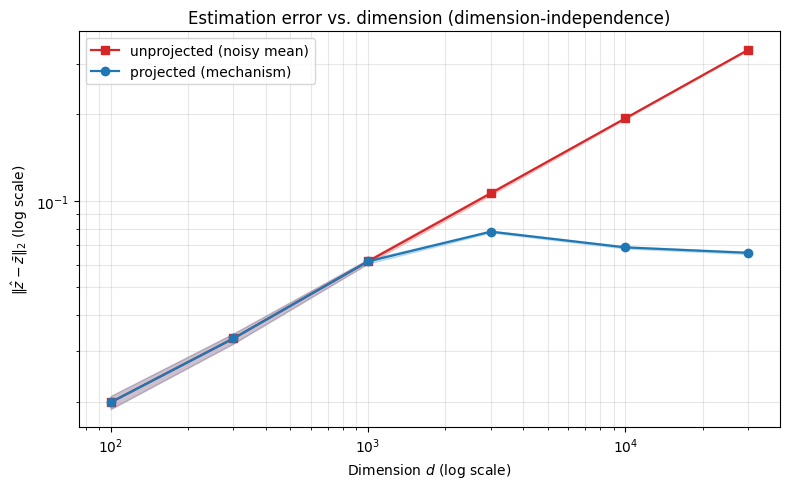

In [3]:
_ = viz.plot_error_vs_dimension(
    dimensions=dims,
    projected_mean=proj_mean, projected_std=proj_std,
    unprojected_mean=unproj_mean, unprojected_std=unproj_std,
    save_path=FIGS_DIR / 'projection_error_vs_dimension.png',
)
print(f'projected error   d={dims[0]} -> d={dims[-1]}:  {proj_mean[0]:.3f} -> {proj_mean[-1]:.3f}  (nearly flat)')
print(f'unprojected error d={dims[0]} -> d={dims[-1]}:  {unproj_mean[0]:.3f} -> {unproj_mean[-1]:.3f}  (~sqrt(d) growth)')


## 3. Lemma 3.1 validation (both branches)

**Lemma 3.1.** `‖ẑ − z̄‖₂ ≤ √(2 L ‖ξ‖_∞ √s)` almost surely, where `ξ = z̃ − z̄`
is the injected noise. We run many trials of **both** the Laplace (`δ = 0`) and
Gaussian (`δ > 0`) branches at a fixed dimension, recover `ξ` from the
mechanism's `z_tilde` output, and scatter the realized error against the bound. Every point
must land **on or below** the `y = x` line. The ground-truth mean is constructed
`s`-sparse with `‖z̄‖₂ < L`, so the precondition `z̄ ∈ K` holds.


In [4]:
d_lem = 5_000
s_lem = 20
n_lem = 10_000
eps_lem = 0.5      # Gaussian branch requires eps < 1; Laplace accepts it too
n_lem_trials = 150

def lemma_bound(L, xi, s):
    return float(np.sqrt(2.0 * L * float(jnp.max(jnp.abs(xi))) * np.sqrt(s)))

bounds, errors, labels = [], [], []
key = jax.random.PRNGKey(SEED + 1)
for branch, delta in [('Laplace', 0.0), ('Gaussian', 1e-5)]:
    z_bar = jnp.asarray(make_sparse_mean(d_lem, s_lem, L, rng))
    for _ in range(n_lem_trials):
        key, sub = jax.random.split(key)
        zhat, z_tilde = projection_mechanism(
            z_bar, epsilon=eps_lem, delta=delta, n=n_lem,
            L=L, s=s_lem, key=sub)
        xi = z_tilde - z_bar
        errors.append(float(jnp.linalg.norm(zhat - z_bar)))
        bounds.append(lemma_bound(L, xi, s_lem))
        labels.append(branch)

errors = np.array(errors); bounds = np.array(bounds); labels = np.array(labels)
violations = int(np.sum(errors > bounds + 1e-6))
print(f'trials={len(errors)}  Lemma 3.1 violations (error > bound): {violations}')
print(f'max error/bound ratio: {np.max(errors / bounds):.4f}  (must be <= 1)')


trials=300  Lemma 3.1 violations (error > bound): 0
max error/bound ratio: 0.3262  (must be <= 1)


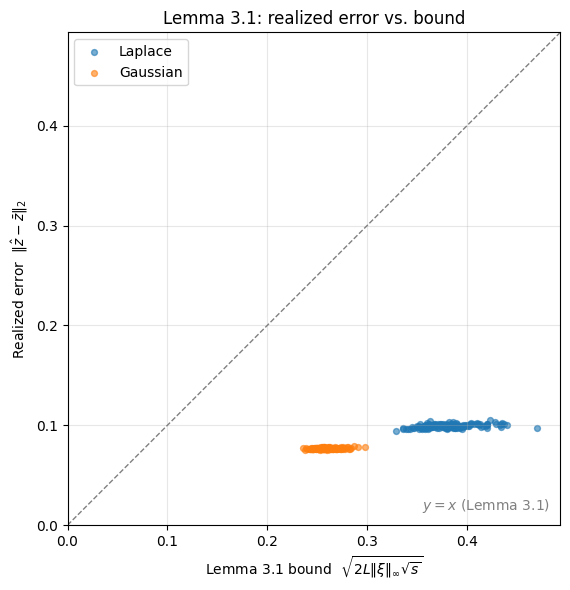

In [5]:
_ = viz.plot_lemma31_bound(
    bound=bounds, error=errors, labels=labels,
    save_path=FIGS_DIR / 'projection_lemma31_bound.png',
)


## 4. Criteo sparse model — empirical gradient sparsity

The hashed logistic-regression reference model
(`dimma.models.hashed_logreg`) keeps the **whole** per-sample gradient sparse:
each example touches one bucket per categorical field plus the dense integer
features and the bias, so nnz ≤ `num_fields + num_dense + 1 = 26 + 13 + 1 = 40`
regardless of the (large) table size. We load Criteo with all 39 features, do the
integer preprocessing here (median-fill → `log1p` → standardize, mirroring
`load_criteo(features="integer")`), hash the 26 categorical columns, and measure
the empirical per-sample gradient sparsity.

> **Memory caveat.** `dimma.train` forms **dense-storage** per-sample gradients of
> shape `(b1, d)`. At `b1 = 4096`, `num_buckets = 1024` (`d ≈ 26 638`) that is
> `≈ 437 MB` for a single anchor batch. Tune `b1` / `num_buckets` to your RAM; here
> we use a subset of rows and read the gradient once, then downscale further in
> Section 5.


In [6]:
split = load_criteo(features='all')
int_cols = split.metadata['int_cols']
cat_cols = split.metadata['cat_cols']
num_dense = len(int_cols)      # 13
num_fields = len(cat_cols)     # 26
print(f'num_dense (integer) = {num_dense}, num_fields (categorical) = {num_fields}')

# Work on a modest subset of the training split to keep memory/time sane.
N_SUB = 3000
x_all = np.asarray(split.x_train)[:N_SUB]        # (N_SUB, 39): 13 int + 26 cat
y_sub = np.asarray(split.y_train)[:N_SUB].astype(np.float32)
x_int_raw = x_all[:, :num_dense]
x_cat_raw = x_all[:, num_dense:]

# Integer preprocessing (mirror load_criteo 'integer' mode): median-fill,
# log1p(clip>=0), standardize. Medians/means/stds from this subset.
medians = np.nanmedian(x_int_raw, axis=0)
x_int = np.where(np.isnan(x_int_raw), medians, x_int_raw).astype(np.float32)
x_int = np.log1p(np.clip(x_int, a_min=0.0, a_max=None))
mu = x_int.mean(axis=0); sd = x_int.std(axis=0); sd = np.where(sd < 1e-8, 1.0, sd)
x_int = (x_int - mu) / sd

# Hash the 26 categorical columns into disjoint per-field bucket blocks.
NUM_BUCKETS = 1024
x_buckets = hash_buckets(x_cat_raw, NUM_BUCKETS)   # (N_SUB, 26) float32 indices
X = np.concatenate([x_int, x_buckets], axis=1).astype(np.float32)  # (N_SUB, 39)
d_model = num_fields * NUM_BUCKETS + num_dense
print(f'assembled feature matrix {X.shape}, model dimension d = {d_model:,}')


num_dense (integer) = 13, num_fields (categorical) = 26
assembled feature matrix (3000, 39), model dimension d = 26,637


In [7]:
# Per-sample gradients via vmap(grad(...)); count nonzeros of the flattened grad.
from jax.flatten_util import ravel_pytree

key = jax.random.PRNGKey(SEED)
params = hashed_init_params(key, num_dense=num_dense,
                            num_fields=num_fields, num_buckets=NUM_BUCKETS)

per_sample_grad = jax.vmap(jax.grad(per_sample_hashed_bce_loss),
                           in_axes=(None, 0, 0))
grads = per_sample_grad(params, jnp.asarray(X), jnp.asarray(y_sub))

flat_fn = jax.vmap(lambda g: ravel_pytree(g)[0])
flat_grads = np.asarray(flat_fn(grads))          # (N_SUB, d_model)
nnz = np.count_nonzero(np.abs(flat_grads) > 1e-12, axis=1)
s_bound = num_fields + num_dense + 1             # 40
print(f'per-sample nnz: min={nnz.min()}, median={int(np.median(nnz))}, '
      f'max={nnz.max()}  (bound s = {s_bound})')
assert nnz.max() <= s_bound, 'gradient exceeded the sparsity bound!'


per-sample nnz: min=40, median=40, max=40  (bound s = 40)


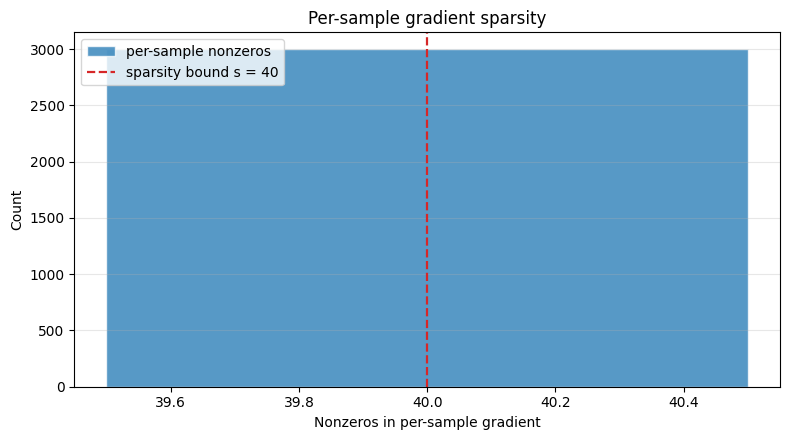

In [8]:
_ = viz.plot_grad_sparsity_histogram(
    nnz_per_sample=nnz, s=s_bound,
    save_path=FIGS_DIR / 'criteo_grad_sparsity_histogram.png',
)


## 5. Private SpiderBoost: projection off vs. on

We run Private SpiderBoost twice on a Criteo subset with the hashed model:
`s=None` (projection **off**) and `s=40` (projection **on**). Both runs use the
**identical** `(ε, δ, T, q, b1, b2, eta)` and the **same seed**, and — crucially —
the **same** `NoiseScales` object (`compute_noise_scales` is called **once**). The
`ℓ₁`-ball projection inside the kernels is post-processing, so the privacy
accounting is unchanged between the two runs.

We downscale `num_buckets` and `b1` here (relative to Section 4's `1024`) purely to
keep the per-sample `(b1, d)` gradient small and the notebook fast.


In [9]:
# Downscaled, self-contained training subset.
NUM_BUCKETS_TR = 256
N_TRAIN = 16_384
N_TEST = 4_000

def build_features(x_raw, medians, mu, sd, num_buckets):
    xi = x_raw[:, :num_dense]
    xi = np.where(np.isnan(xi), medians, xi).astype(np.float32)
    xi = np.log1p(np.clip(xi, a_min=0.0, a_max=None))
    xi = (xi - mu) / sd
    xb = hash_buckets(x_raw[:, num_dense:], num_buckets)
    return np.concatenate([xi, xb], axis=1).astype(np.float32)

xtr_raw = np.asarray(split.x_train)[:N_TRAIN]
xte_raw = np.asarray(split.x_test)[:N_TEST]
ytr = np.asarray(split.y_train)[:N_TRAIN].astype(np.float32)
yte = np.asarray(split.y_test)[:N_TEST].astype(np.float32)

med_tr = np.nanmedian(xtr_raw[:, :num_dense], axis=0)
xi_tr = np.where(np.isnan(xtr_raw[:, :num_dense]), med_tr, xtr_raw[:, :num_dense]).astype(np.float32)
xi_tr = np.log1p(np.clip(xi_tr, a_min=0.0, a_max=None))
mu_tr = xi_tr.mean(axis=0); sd_tr = xi_tr.std(axis=0); sd_tr = np.where(sd_tr < 1e-8, 1.0, sd_tr)

X_tr = jnp.asarray(build_features(xtr_raw, med_tr, mu_tr, sd_tr, NUM_BUCKETS_TR))
X_te = jnp.asarray(build_features(xte_raw, med_tr, mu_tr, sd_tr, NUM_BUCKETS_TR))
y_tr = jnp.asarray(ytr); n_train = X_tr.shape[0]
print(f'train {X_tr.shape}, test {X_te.shape}, d = {num_fields*NUM_BUCKETS_TR+num_dense:,}')


train (16384, 39), test (4000, 39), d = 6,669


In [10]:
base_kwargs = dict(
    epsilon=1.0,               # modest budget -> noise large enough that the
    delta=1.0 / (1.1 * n_train),  # l1-ball projection actually engages at anchors
    L0=1.0, L1=1.0,
    T=12, q=4,
    b1=2048, b2=256,
    eta=0.05,
    seed=SEED,
)
config_off = TrainConfig(**base_kwargs, s=None)
config_on  = TrainConfig(**base_kwargs, s=40)

# Accounting is computed ONCE and reused for BOTH runs (projection is
# post-processing; NoiseScales does not depend on s).
noise_scales = compute_noise_scales(
    L0=base_kwargs['L0'], L1=base_kwargs['L1'],
    epsilon=base_kwargs['epsilon'], delta=base_kwargs['delta'],
    T=base_kwargs['T'], q=base_kwargs['q'], n=n_train,
    b1=base_kwargs['b1'], b2=base_kwargs['b2'])
print('sigma1     =', f'{noise_scales.sigma1:.4e}')
print('sigma2     =', f'{noise_scales.sigma2:.4e}')
print('sigma2_hat =', f'{noise_scales.sigma2_hat:.4e}')


sigma1     = 1.5285e-03
sigma2     = 1.2228e-02
sigma2_hat = 2.4456e-02


In [11]:
init_p = hashed_init_params(jax.random.PRNGKey(SEED), num_dense=num_dense,
                            num_fields=num_fields, num_buckets=NUM_BUCKETS_TR)

batch_forward = jax.jit(jax.vmap(hashed_forward, in_axes=(None, 0)))

def evaluate(params):
    logits = np.asarray(batch_forward(params, X_te))
    probs = 1.0 / (1.0 + np.exp(-logits))
    bce = float(np.mean(np.maximum(logits, 0) - logits * yte
                        + np.log1p(np.exp(-np.abs(logits)))))
    auc = float(roc_auc_score(yte, probs))
    return bce, auc

def make_callback():
    steps, bce_hist, auc_hist = [], [], []
    def cb(info):
        if info.is_anchor:
            bce, auc = evaluate(info.params)
            steps.append(info.step); bce_hist.append(bce); auc_hist.append(auc)
    return cb, steps, bce_hist, auc_hist

cb_off, steps_off, bce_off, auc_off = make_callback()
res_off = dimma.train(X_tr, y_tr, per_sample_loss_fn=per_sample_hashed_bce_loss,
                      init_params=init_p, config=config_off,
                      noise_scales=noise_scales, sampler='poisson',
                      step_callback=cb_off)
print('projection OFF done; wall', f'{sum(res_off.history.wall_time_s):.1f}s')

cb_on, steps_on, bce_on, auc_on = make_callback()
res_on = dimma.train(X_tr, y_tr, per_sample_loss_fn=per_sample_hashed_bce_loss,
                     init_params=init_p, config=config_on,
                     noise_scales=noise_scales, sampler='poisson',
                     step_callback=cb_on)
print('projection ON  done; wall', f'{sum(res_on.history.wall_time_s):.1f}s')


projection OFF done; wall 0.9s


projection ON  done; wall 0.8s


Identical NoiseScales across both runs: True
max |grad_norm(on) - grad_norm(off)| = 1.9734e-02  (nonzero => projection engaged)


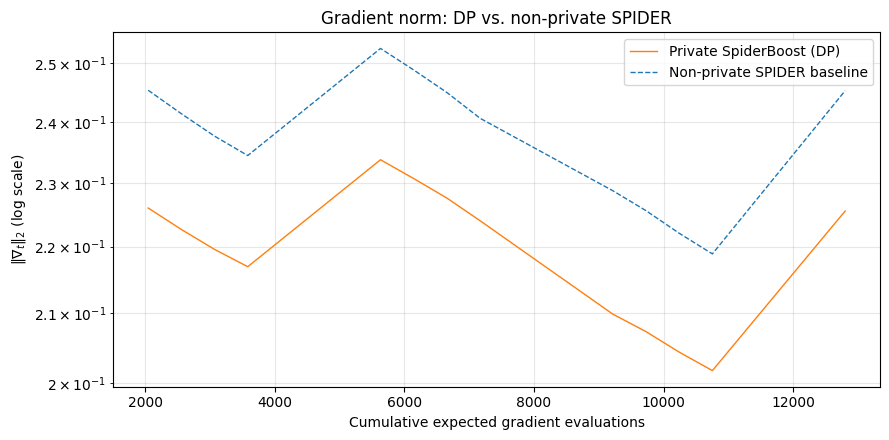

In [12]:
# Sanity: both runs consumed the SAME accounting object -> privacy unchanged.
assert res_off.history.noise_scales == res_on.history.noise_scales
print('Identical NoiseScales across both runs:', res_off.history.noise_scales == res_on.history.noise_scales)

gn_off = np.asarray(res_off.history.grad_norm)
gn_on = np.asarray(res_on.history.grad_norm)
print(f'max |grad_norm(on) - grad_norm(off)| = {np.max(np.abs(gn_on - gn_off)):.4e}  '
      f'(nonzero => projection engaged)')

cum = np.array([model.expected_grad_evals(t, base_kwargs['q'], base_kwargs['b1'], base_kwargs['b2'])
                for t in range(base_kwargs['T'] + 1)])

# Reuse the existing comparison helper. NOTE: both curves here are DP; the helper's
# baked-in legend labels map as: "Private SpiderBoost (DP)" = projection ON,
# "Non-private SPIDER baseline" = projection OFF.
_ = viz.plot_grad_norm_comparison(
    dp_grad_norm=res_on.history.grad_norm, dp_cumulative_evals=cum,
    baseline_grad_norm=res_off.history.grad_norm, baseline_cumulative_evals=cum,
    save_path=FIGS_DIR / 'projection_spiderboost_grad_norm.png',
)


run                   test BCE    test AUC
projection OFF          0.6499      0.5977
projection ON           0.6504      0.5956


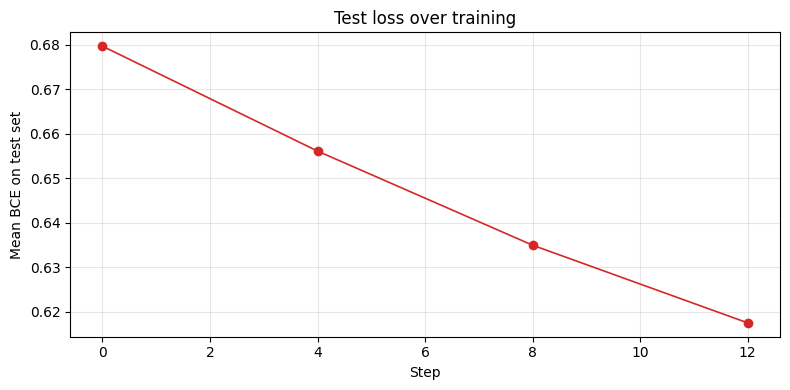

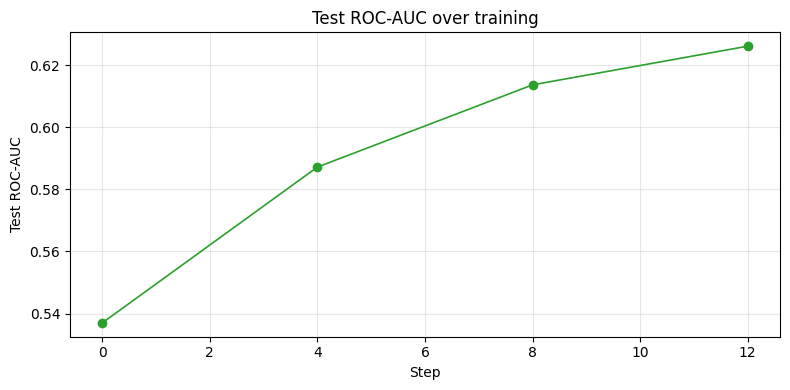

In [13]:
_ = viz.plot_test_loss(steps_on, bce_on, save_path=FIGS_DIR / 'projection_spiderboost_test_bce.png')
_ = viz.plot_auc_history(steps_on, auc_on, save_path=FIGS_DIR / 'projection_spiderboost_auc.png')

def final_metrics(res):
    return evaluate(res.params_random)

bce_off_f, auc_off_f = final_metrics(res_off)
bce_on_f, auc_on_f = final_metrics(res_on)
print(f'{"run":<18}{"test BCE":>12}{"test AUC":>12}')
print(f'{"projection OFF":<18}{bce_off_f:>12.4f}{auc_off_f:>12.4f}')
print(f'{"projection ON":<18}{bce_on_f:>12.4f}{auc_on_f:>12.4f}')


## 6. Caveats

- **The projected estimator is biased.** Euclidean projection onto `K` is a
  nonlinear contraction, so `E[ẑ] ≠ z̄` in general. In an iterative optimizer this
  bias can slow or distort convergence — which is exactly why the projection
  defaults to **off** in the SpiderBoost kernels and is opt-in via `TrainConfig.s`.
- **The paper's bias-reduction machinery is out of scope.** Algorithms 2 and 3 of
  Ghazi et al. 2024 (randomized exponentially-increasing batch sizes + a
  telescoping debiased estimator, and a randomly-stopped SGD driven by a DP filter)
  are **not** implemented here. This notebook demonstrates only the Algorithm 1
  primitive and its default-off post-processing hook.
- **Accounting is unchanged.** The projection is post-processing of a private
  quantity, so both Section 5 runs share one `NoiseScales` object; sparsity `s`
  never enters the privacy calculation, only the projection radius.
- **`s` is a required upper bound, never estimated.** All rates and the projection
  radius depend on knowing an upper bound on the per-sample gradient sparsity;
  adapting to unknown `s` is an open problem in the paper.
- See **ADR-0003** (`docs/adr/0003-projection-mechanism-layering.md`, written in
  Phase 6) for the layering rationale and the expected-vs-realized batch-size
  caveat.
